In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/01-TrackLength/"

In [37]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "very_long_prot":1500, 
}

In [38]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
elongation_rate = 5
for i in range(10):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if i == 0:
        datas = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5.csv"))

In [39]:
# datas = pd.read_csv(os.path.join(path, "datas_track_length.csv"), index_col="Unnamed: 0")
datas

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
0,0.0,2785.206030,0
1,0.1,2785.929648,0
2,0.2,2786.653266,0
3,0.3,2787.376884,0
4,0.4,2788.100503,0
...,...,...,...
8399995,83999.5,2506.130653,9
8399996,83999.6,2506.854271,9
8399997,83999.7,2507.577889,9
8399998,83999.8,2508.301508,9


In [40]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
first = True
t = 10

dt = t*0.1
for length_track in [50, 100, 150, 200, 500, 1000, 5000, 10000, 20000, 50000]:
    print(length_track)
    
    for i in range(10):
        datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
        if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [50, 100, 150, 200, 500, 1000, 5000, 10000, 20000, 50000]):
            
            (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                   i,
                                                   normalise_intensity=1,
                                                   delta_t=dt,
                                                   rtol=1e-1,
                                                   nb_missing_point=0,
                                                   )

            
            (x_auto, 
             y_auto, 
             k, c,
             elongation_r, 
             translation_init_r,
             perr) = single_track_analysis(x, 
                                         y, 
                                         delta_t = dt,
                                         protein_size=prot_aa_size["very_long_prot"],
                                         suntag_size =prot_aa_size["32xsuntag"], 
                                         repetition_suntag = 32,
                                         mm=None,
                                         method="exact",
                                         simulation=True)
            if first:
                results = pd.DataFrame({"elongation_r":elongation_r, 
                                        "init_translation_r":translation_init_r, 
                                        "dt":dt,
                                        "long_track":datas2.shape[0],
                                        "k":k,
                                        "c":c,
                                       "id":i},
                                      index=[0])
                first = False
            
            else:
                results = pd.concat([results, 
                                pd.DataFrame({"elongation_r":elongation_r, 
                                              "init_translation_r":translation_init_r, 
                                              "dt":dt, 
                                              "long_track":datas2.shape[0],
                                              "k":k,
                                                "c":c,
                                              "id":i}, index=[0])
                                ], ignore_index=True)
                    
results.to_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"))

50
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
100
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
150
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
200
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
500
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
1000
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
62 32
5000
62 32
Sorry, due to the complexity of the equation, there is a chance that M or N are too big, and the number are too large to be processed now (cause of factorial).
The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
62 32
Sorry, due to the complexity of the equation, there is a chance that M or N are too big, and the number are too large to be processed now (cause of factorial).
The model function generated NaN values and the fit aborted! 

In [41]:
# results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_24.csv"), index_col="Unnamed: 0")

In [42]:
results.groupby(by=['dt', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].mean()

elongation_r  init_translation_r         k          c
dt  long_track                                                       
1.0 50            137.918544           81.107500  5.544464  81.107500
    100            71.607780           18.926729  2.878705  18.926729
    150            60.631217           13.775740  2.437436  13.775740
    200            33.508448           21.909795  1.347073  21.909795
    500            15.808846            0.722249  0.635532   0.722249
    1000           12.615378            0.625056  0.507151   0.625056
    5000                 NaN                 NaN       NaN        NaN
    10000                NaN                 NaN       NaN        NaN
    20000                NaN                 NaN       NaN        NaN
    50000                NaN                 NaN       NaN        NaN

In [43]:
results.groupby(by=['dt', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].std()

elongation_r  init_translation_r         k           c
dt  long_track                                                        
1.0 50             91.354133          107.272365  3.672528  107.272365
    100            34.666116           17.425173  1.393613   17.425173
    150            25.091419           14.245327  1.008700   14.245327
    200            12.564752           57.722124  0.505116   57.722124
    500             5.687140            0.676127  0.228629    0.676127
    1000            6.572572            0.812796  0.264224    0.812796
    5000                 NaN                 NaN       NaN         NaN
    10000                NaN                 NaN       NaN         NaN
    20000                NaN                 NaN       NaN         NaN
    50000                NaN                 NaN       NaN         NaN

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


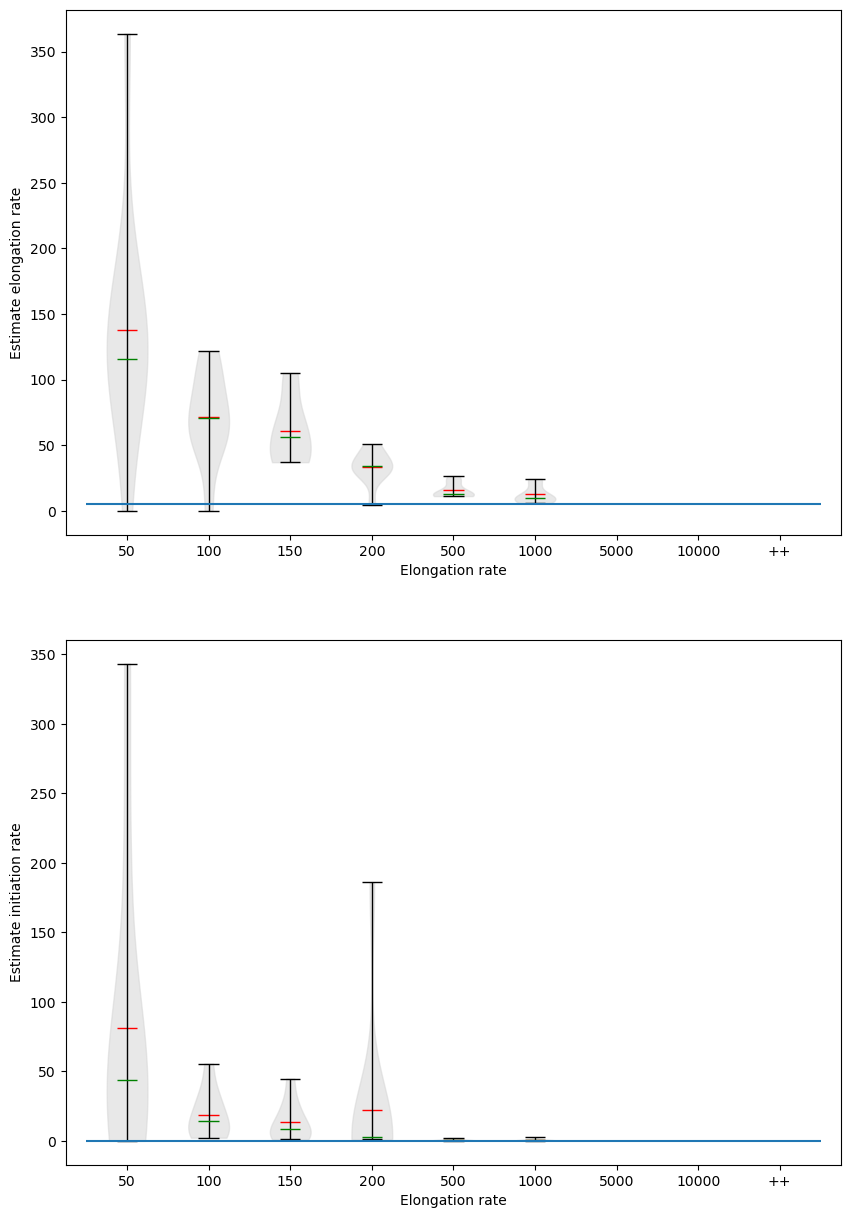

In [44]:
fig, ax = plt.subplots(2,1)


50,100,150, 200, 500
violin = ax[0].violinplot(dataset = [
#     results[(results.dt == 0.1) & (results.long_track == 50)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 100)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 150)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 200)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 500)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 1000)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 5000)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 10000)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 20000)]["elongation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 50000)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 50)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 100)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 150)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 200)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 500)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 1000)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 5000)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 10000)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 20000)]["elongation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 50000)]["elongation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 50) & (results.elongation_r>0)]["elongation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 100) & (results.elongation_r>0)]["elongation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 150) & (results.elongation_r>0)]["elongation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 200) & (results.elongation_r>0)]["elongation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 500) & (results.elongation_r>0)]["elongation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 1000) & (results.elongation_r>0)]["elongation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track > 1000) & (results.elongation_r>0)]["elongation_r"].values
    ],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
# results.boxplot(['init_translation_r'] , 
#                by=['dt', "long_track"], 
#                grid=False, 
#                ax = ax[1],
#                rot=90,
#                boxprops=dict(linestyle='-', linewidth=1.5, color="black"),
#                medianprops=dict(linestyle='-', linewidth=1.5, color="red"),
#                )


violin = ax[1].violinplot(dataset = [
#     results[(results.dt == 0.1) & (results.long_track == 50)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 100)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 150)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 200)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 500)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 1000)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 5000)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 10000)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 20000)]["init_translation_r"].values,
#     results[(results.dt == 0.1) & (results.long_track == 50000)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 50)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 100)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 150)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 200)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 500)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 1000)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 5000)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 10000)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 20000)]["init_translation_r"].values,
    results[(results.dt == 1.0) & (results.long_track == 50000)]["init_translation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 50) & (results.elongation_r>0)]["init_translation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 100) & (results.elongation_r>0)]["init_translation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 150) & (results.elongation_r>0)]["init_translation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 200) & (results.elongation_r>0)]["init_translation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 500) & (results.elongation_r>0)]["init_translation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track == 1000) & (results.elongation_r>0)]["init_translation_r"].values,
    # results[(results.dt == 60.0) & (results.long_track > 1000) & (results.elongation_r>0)]["init_translation_r"].values
    ],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1

group = ['dt', "long_track"]
column = 'elongation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
group = ['dt', "long_track"]
column = 'init_translation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)

def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Elongation rate')
# set style for the axes
labels = [50,100,150,200,500,1000, 5000,10000, "++"]
for a in ax:
    set_axis_style(a, labels)

ax[0].set_ylabel("Estimate elongation rate")
ax[1].set_ylabel("Estimate initiation rate")

# ax[0].set_ylim(-5,50)
# ax[1].set_ylim(-1, 20)
ax[0].hlines(elongation_rate, 0.5, 9.5)
ax[1].hlines(0.05, 0.5, 9.5)
fig.set_size_inches((10,15))
fig.savefig(os.path.join(path_save, "results_length_boxplot_exact_dt1_0.05_5.eps"), dpi=300)

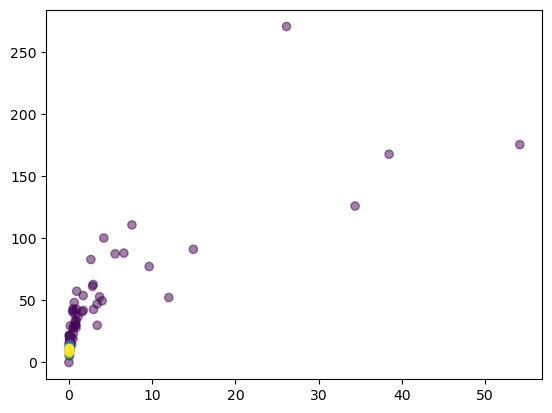

In [16]:
fig, ax = plt.subplots()
ax.scatter(results["init_translation_r"], results["elongation_r"], c=results["long_track"], alpha=0.5)
# ax.set_xlim(0,50)
# ax.set_ylim(0,50)

In [ ]:
results[(results.dt == 60.0) & (results.long_track >1000) & (results.elongation_r>0)]

In [ ]:
results_group = results.groupby(["dt", "long_track"]).mean()
results_group.reset_index(inplace=True)

elongation_ref = 24

results_group["elongation_r_diff"] = elongation_ref-results_group['elongation_r']
results_group["elongation_r_ratio"] = 100*results_group["elongation_r"]/elongation_ref - 100
results_group["elongation_r_ratio"]= np.abs(results_group["elongation_r_ratio"])


results_group["init_translation_r_diff"] = 20-results_group['init_translation_r']
results_group["init_translation_r_ratio"] = 100*results_group["init_translation_r"]/20 -100
results_group["init_translation_r_ratio"] = np.abs(results_group["init_translation_r_ratio"])

results_group

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='elongation_r_ratio')

# Create the heatmap
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
# plt.figure(figsize=(8, 6))
ax1 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100,
                 ax=ax1)
# Invert the y-axis
ax1.invert_yaxis()
ax1.set_title("Heatmap of elongation rate Values")
ax1.set_xlabel("time step")
ax1.set_ylabel("track length")



heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')
ax2 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100, 
                  ax = ax2
                )
# Invert the y-axis
ax2.invert_yaxis()
ax2.set_title("Heatmap of initiation rate Values")
ax2.set_xlabel("time step")
ax2.set_ylabel("track length")

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap=combined_colors,
                 vmin = 0,
                 vmax = 200
                )
# Invert the y-axis
ax.invert_yaxis()

plt.title("Heatmap of initiation rate Values")
plt.xlabel("time step")
plt.ylabel("track length")
plt.show()